In [1]:
# ==========================================
# STEP 1: Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

c:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
# ==========================================
# STEP 2: Load the Dataset
# ==========================================

# Load the cleaned dataset
df = pd.read_csv("C:\\Users\\LENOVO\Downloads\\Cleaned_Customer_Data.csv")

# Display the first five rows
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


In [5]:
# ==========================================
# STEP 3: Understand the Dataset
# ==========================================

# Display the number of rows and columns
print("Shape of Dataset:", df.shape)

print("\n")

# Display column names
print("Column Names:\n")
print(df.columns)

print("\n")

# Display information about the dataset
df.info()

print("\n")

# Display descriptive statistics
df.describe()

Shape of Dataset: (7043, 36)


Column Names:

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status'],
      dtype='str')


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                           

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


Customer Status Distribution:

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


Percentage Distribution:

Customer Status
Stayed     67.016896
Churned    26.536987
Joined      6.446117
Name: proportion, dtype: float64


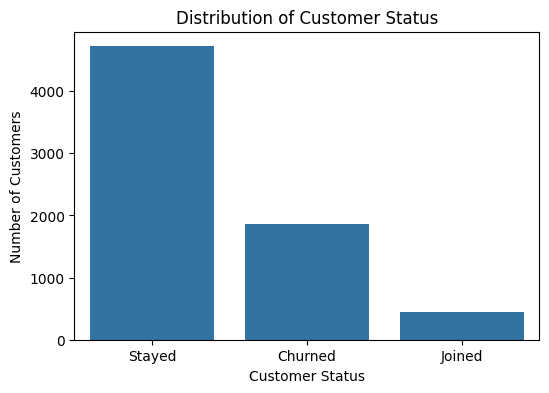

In [6]:
# ==========================================
# STEP 4 : Explore the Target Variable
# ==========================================

# Display the number of customers in each category
print("Customer Status Distribution:\n")
print(df["Customer Status"].value_counts())

print("\n")

# Display the percentage distribution
print("Percentage Distribution:\n")
print(df["Customer Status"].value_counts(normalize=True) * 100)

# Plot the distribution
plt.figure(figsize=(6,4))

sns.countplot(x="Customer Status", data=df)

plt.title("Distribution of Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
# ==========================================
# STEP 5 : Prepare Data for Classification
# ==========================================

# Copy the dataset to avoid modifying the original
classification_df = df.copy()

# Remove Customer ID since it is only an identifier
classification_df = classification_df.drop("Customer ID", axis=1)

# Separate Features (X) and Target (y)
X = classification_df.drop("Customer Status", axis=1)
y = classification_df["Customer Status"]

print("Shape of Feature Matrix (X):", X.shape)
print("Shape of Target Variable (y):", y.shape)

Shape of Feature Matrix (X): (7043, 34)
Shape of Target Variable (y): (7043,)


In [8]:
# ==========================================
# STEP 6 : Encode Categorical Variables
# ==========================================

# Import the required libraries
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# Identify all categorical columns in X
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

# Apply One-Hot Encoding to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

# Transform the feature matrix
X_encoded = preprocessor.fit_transform(X)

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Display the class mapping
print("\nCustomer Status Encoding:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

print("\nShape of Encoded Feature Matrix:", X_encoded.shape)


Categorical Columns:
Index(['Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method'],
      dtype='str')

Customer Status Encoding:
Churned --> 0
Joined --> 1
Stayed --> 2

Shape of Encoded Feature Matrix: (7043, 1154)


In [9]:
# ==========================================
# STEP 7 : Split Data into Training and Testing Sets
# ==========================================

from sklearn.model_selection import train_test_split

# Split the encoded data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Display the shape of each dataset
print("Training Feature Set :", X_train.shape)
print("Testing Feature Set  :", X_test.shape)

print()

print("Training Target Set  :", y_train.shape)
print("Testing Target Set   :", y_test.shape)

Training Feature Set : (5634, 1154)
Testing Feature Set  : (1409, 1154)

Training Target Set  : (5634,)
Testing Target Set   : (1409,)


In [10]:
# ==========================================
# STEP 8 : Train Logistic Regression Model
# ==========================================

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [11]:
# ==========================================
# STEP 9 : Make Predictions
# ==========================================

# Predict the customer status for the test data
y_pred = log_model.predict(X_test)

print("Predictions Completed Successfully!")

# Display the first 10 predictions
print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Actual Values:")
print(y_test[:10])

Predictions Completed Successfully!

First 10 Predictions:
[2 0 0 2 2 1 2 1 0 2]

First 10 Actual Values:
[2 0 2 0 2 1 2 0 0 2]


In [12]:
# ==========================================
# STEP 10 : Evaluate Logistic Regression
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

# Print evaluation metrics
print("========== Logistic Regression Performance ==========\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

========== Logistic Regression Performance ==========

Accuracy  : 0.7779
Precision : 0.7725
Recall    : 0.7779
F1 Score  : 0.7733

Classification Report

              precision    recall  f1-score   support

     Churned       0.61      0.51      0.56       374
      Joined       0.50      0.63      0.56        91
      Stayed       0.86      0.90      0.88       944

    accuracy                           0.78      1409
   macro avg       0.66      0.68      0.66      1409
weighted avg       0.77      0.78      0.77      1409



<Figure size 700x600 with 0 Axes>

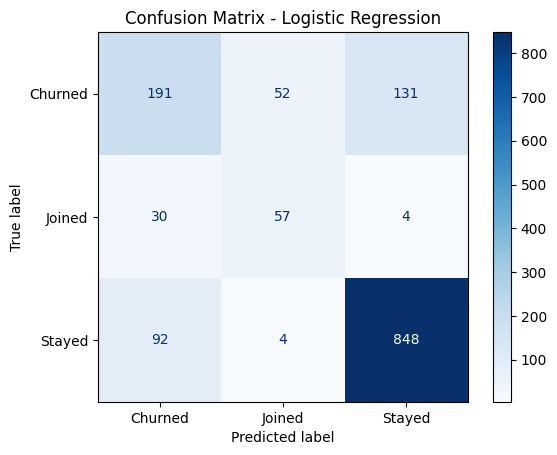

In [13]:
# ==========================================
# STEP 11 : Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Random Forest Model Trained Successfully!
Predictions Completed Successfully!

First 10 Predictions:
[2 0 2 2 2 0 2 0 0 2]
========== Random Forest Performance ==========

Accuracy  : 0.8417
Precision : 0.8350
Recall    : 0.8417
F1 Score  : 0.8347

Classification Report

              precision    recall  f1-score   support

     Churned       0.74      0.63      0.68       374
      Joined       0.81      0.57      0.67        91
      Stayed       0.88      0.95      0.91       944

    accuracy                           0.84      1409
   macro avg       0.81      0.72      0.75      1409
weighted avg       0.83      0.84      0.83      1409



<Figure size 700x600 with 0 Axes>

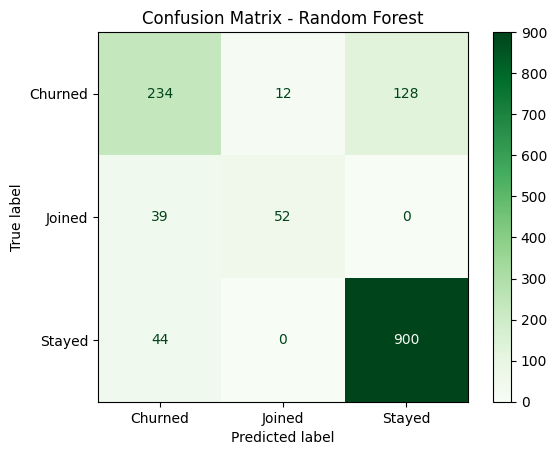

In [14]:
# ==========================================
# STEP 12 : Train Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")
# ==========================================
# STEP 13 : Random Forest Predictions
# ==========================================

# Predict customer status
rf_pred = rf_model.predict(X_test)

print("Predictions Completed Successfully!")

print("\nFirst 10 Predictions:")
print(rf_pred[:10])

# ==========================================
# STEP 14 : Evaluate Random Forest
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("========== Random Forest Performance ==========\n")

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

# ==========================================
# STEP 15 : Random Forest Confusion Matrix
# ==========================================

rf_cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(7,6))

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Random Forest")

plt.show()

Top 10 Important Features:

                                           Feature  Importance
1145                   remainder__Tenure in Months    0.088175
1149                      remainder__Total Charges    0.083682
1153                      remainder__Total Revenue    0.082589
1152        remainder__Total Long Distance Charges    0.060366
1148                     remainder__Monthly Charge    0.040848
1144                remainder__Number of Referrals    0.036717
1146  remainder__Avg Monthly Long Distance Charges    0.032924
1139                                remainder__Age    0.032689
1142                           remainder__Latitude    0.032395
1141                           remainder__Zip Code    0.031708


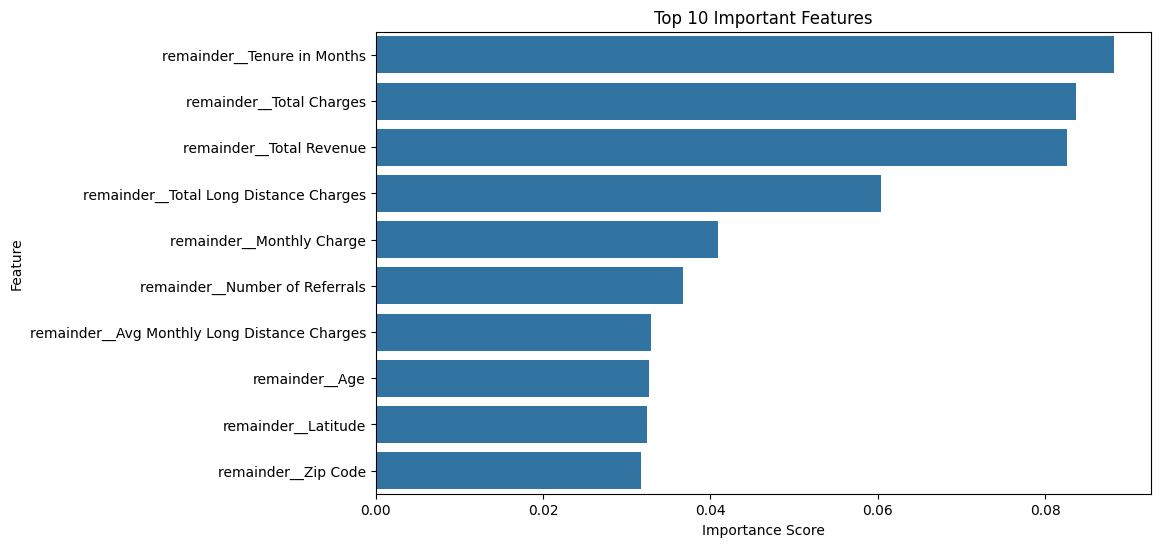

In [15]:
# ==========================================
# STEP 16 : Feature Importance
# ==========================================

# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Get importance scores
importance = rf_model.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10 Important Features
print("Top 10 Important Features:\n")
print(feature_importance.head(10))

# Plot Top 10 Features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()